# Sesión conjunta · ¿Cuántas neuronas responden?
### L6 · viernes 18 de septiembre

Hoy calculamos, todos juntos, **la fracción de neuronas de su área que responden a las rejillas en
movimiento**. Es el único número que las once parejas van a calcular igual, y es el que vamos a
poner lado a lado el día de los pósters.

**Esto no es tarea.** Sale de esta sesión hecho. Pero debe incluirse en el notebook del proyecto final, y el resultado en el poster.

## Cómo se usa este notebook

Cada paso tiene dos celdas:

- Una **celda de texto con viñetas**: eso es lo que la celda de código tiene que hacer. Conviértanlo
  en un prompt, pídanle el código al modelo, péguenlo abajo y córranlo.
- Una **celda de código vacía**: ahí va lo que les devolvió, ya revisado.

Al final de cada paso hay una línea de **cómo saber si quedó bien**. Úsenla siempre. El modelo
escribe código que corre y da números equivocados sin avisar, y esa es la única defensa que tienen.

## Un consejo que les va a ahorrar tiempo

Cuando le pidan el código de los Pasos 2 en adelante, **péguenle primero la salida del paso 1**, la lista de variables del
archivo. Si el modelo no sabe cómo está hecho el archivo, se lo inventa: va a suponer nombres de
columnas que no existen y el código va a fallar o, peor, va a correr sobre lo que no es.

---
## Descargar los datos

Esta celda ya está escrita. Lo único que cambian es `MI_AREA`.

In [83]:
!pip install gdown -q
import numpy as np, gdown

# ---- Los ocho archivos. Cambien MI_AREA por la que les tocó en el sorteo. ----
IDS = {
    "VISp": "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",    # 382 neuronas
    "VISl": "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",    # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd": "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",     # 301 neuronas
    "LP": "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",      # 431 neuronas
}

MI_AREA = "VISam"      # <<<<<<<<<<  CAMBIEN ESTO

gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print("\nÁrea:", MI_AREA, " ·  variables del archivo:")
print(d.files)

Downloading...
From: https://drive.google.com/uc?id=1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO
To: /content/datos.npz
100%|██████████| 22.8M/22.8M [00:00<00:00, 145MB/s]


Área: VISam  ·  variables del archivo:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## PASO 1 · Ver qué hay en el archivo

Lo que tiene que hacer la celda de abajo:

- Cuántas neuronas hay en total
- Cuántos ratones distintos (la columna u_raton)
- Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
- Cuántos PAs hay en total

> **Cómo saber si quedó bien.** El número de neuronas tiene que coincidir con el de la tabla del enunciado, y los ratones tienen que ser 5. Si no, están cargando el archivo equivocado.

In [39]:
# Ver el Archivo
archivo = d.files

print("DATOS")
n_neuronas = np.unique(d["s_unidad"]).size
n_raton = np.unique(d["u_raton"]).size
clases, n_ensayos = np.unique(d["e_clase"], return_counts=True)
n_PAs = len(d["s_t"])


print("Numero Neuronas: ", n_neuronas)
print("Numero Ratones: ", n_raton)
print("Ensayos por clase:")
for clase, cantidad in zip(clases, n_ensayos):
    print(f"  {clase}: {cantidad}") #AI para imprimir dos arrays
print("Numero PA's: ", n_PAs)


DATOS
Numero Neuronas:  368
Numero Ratones:  5
Ensayos por clase:
  drifting_gratings: 2000
  flashes: 750
  natural_movie_one: 40
  natural_scenes: 2000
  spontaneous: 750
  static_gratings: 1250
Numero PA's:  5761044


---
## PASO 2 · Separar los ensayos que nos interesan

Lo que tiene que hacer la celda de abajo:

- Los índices de los ensayos cuya clase es drifting_gratings, que son las rejillas en movimiento
- Los índices de los ensayos cuya clase es spontaneous, que es la pantalla gris sin estímulo
- Imprimir cuántos hay de cada uno

> **Cómo saber si quedó bien.** Deben salir unos 2000 ensayos de rejillas y unos 750 de espontáneo, que son 400 y 150 por cada uno de los 5 ratones.

In [40]:
# Selección datos
e_drifting = np.where(d["e_clase"] == "drifting_gratings")[0]
e_spontaneous = np.where(d["e_clase"] == "spontaneous")[0]

print("Ensayos drifting_gratings:", len(e_drifting))
print("Ensayos spontaneous:", len(e_spontaneous))

Ensayos drifting_gratings: 2000
Ensayos spontaneous: 750


---
## PASO 3 · La tasa de disparo de cada neurona en cada ensayo

Lo que tiene que hacer la celda de abajo:

- Para cada neurona y cada ensayo de rejilla, contar los PAs que caen entre 0 y 2 segundos y dividir por 2. Eso es la tasa evocada, en hercios
- Hacer lo mismo con los ensayos de espontáneo, también entre 0 y 2 segundos. Esa es la tasa basal
- Guardar las dos como matrices con una fila por neurona y una columna por ensayo
- Importante para el prompt: s_unidad dice a qué neurona pertenece cada PA y s_ensayo a qué ensayo, y los dos son ÍNDICES de las tablas u_ y e_, no identificadores
- Y esto también, o el resultado sale mal sin avisar: la tabla de ensayos trae los CINCO RATONES JUNTOS, y cada neurona solo vio los ensayos de SU ratón. Hay que emparejar u_raton con e_raton y quedarse, para cada neurona, solo con sus propias columnas

> **Cómo saber si quedó bien.** La tasa evocada mediana tiene que estar entre 1 y 30 Hz. Si les da 0, casi seguro no emparejaron los ratones: están promediando cada neurona sobre 2000 ensayos cuando solo vio 400, y los otros 1600 son ceros que no significan nada.

In [79]:
# Tasa de disparo
# Tasa evocada
condicion_pas = (np.isin(d["s_ensayo"], e_drifting) & (d["s_t"] >= 0) &(d["s_t"] <= 2) & (d["u_raton"][d["s_unidad"]] == d["e_raton"][d["s_ensayo"]]))

ensayos_bien_Pas = d["s_ensayo"][condicion_pas]
neuronas_bien_Pas = d["s_unidad"][condicion_pas]

pares, n_T_PAs = np.unique(np.column_stack((neuronas_bien_Pas, ensayos_bien_Pas)), axis=0, return_counts=True) #AI, como guardar los datos
tasas = n_T_PAs / 2
tasas_evocadas_PAs = np.column_stack((pares[:, 0], pares[:, 1],tasas)) #AI, como guardar los datos

mediana_tasa_evocada_Pas = np.median(tasas)
print("Mediana de la tasa evocada:", f"{mediana_tasa_evocada_Pas:.2f} Hz")

# Tasa Basal
clase_ensayo = d["e_clase"][d["s_ensayo"]]
condicion_espo = ((clase_ensayo == "spontaneous") & (d["s_t"] >= 0) & (d["s_t"] <= 2) & (d["u_raton"][d["s_unidad"]] == d["e_raton"][d["s_ensayo"]]))

ensayos_bien_espo = d["s_ensayo"][condicion_espo]
neuronas_bien_espo = d["s_unidad"][condicion_espo]

pares_espo, n_T_PAs_espo = np.unique(np.column_stack((neuronas_bien_espo, ensayos_bien_espo)), axis=0, return_counts=True)
tasas_espo = n_T_PAs_espo / 2
tasas_espontaneas_PAs = np.column_stack((pares_espo[:, 0], pares_espo[:, 1], tasas_espo))

mediana_tasa_espontanea = np.median(tasas_espo)
print("Mediana de la tasa espontánea:", f"{mediana_tasa_espontanea:.2f} Hz")

# Matrices
neuronas = np.unique(d["s_unidad"])

ensayos_PAs = np.unique(e_drifting)
matriz_tasas_evocadas = np.zeros((len(neuronas), len(ensayos_PAs)))

for (neurona, ensayo), tasa in zip(pares, tasas):
    i = np.where(neuronas == neurona)[0][0]
    j = np.where(ensayos_PAs == ensayo)[0][0]
    matriz_tasas_evocadas[i, j] = tasa

ensayos_spont = np.unique(ensayos_bien_espo)
matriz_tasas_espontaneas = np.zeros((len(neuronas), len(ensayos_spont)))

for (neurona, ensayo), tasa in zip(pares_espo, tasas_espo):
    i = np.where(neuronas == neurona)[0][0]
    j = np.where(ensayos_spont == ensayo)[0][0]
    matriz_tasas_espontaneas[i, j] = tasa

#print("Matriz de tasas evocadas:")
#print(matriz_tasas_evocadas)
#print("Matriz de tasas espontáneas:")
#print(matriz_tasas_espontaneas)

Mediana de la tasa evocada: 5.00 Hz
Mediana de la tasa espontánea: 4.50 Hz



--
## PASO 4 · ¿Cuáles responden?

Lo que tiene que hacer la celda de abajo:

- Para cada neurona, el Z-score: la tasa evocada promedio menos la basal promedio, dividido por la desviación estándar de su propia basal. Todo calculado solo sobre los ensayos de su ratón
- Calcula la respuesta evocada para cada una de las combinaciones de caracteristica de estímulo posibles (direcciones, frecuencias temporales, frecuencias espaciales).
- Identifica la combinación que genera la tasa de disparo máxima (condición preferida) para cada neurona y calcula el z-score usando solo los ensayos de esta combinación.
- Contar cuántas neuronas tienen un Z-score de 2,5 o más
- La fracción respondedora es ese número dividido por el total de neuronas
- Imprimir la fracción como porcentaje

> **Cómo saber si quedó bien.** Si les da 0 % o más del 95 %, revisen el paso 3 antes de seguir: casi siempre es que no emparejaron los ratones. Cualquier cosa entre esos dos extremos es un resultado, no un error. En VISp, con umbral 2,5, da alrededor del 13 % si combinan todas las características del estímulo.

In [99]:
# Z-score
# Modificado con AI, volverlo una funcion
def calcular_z_score(neurona, ensayos_estimulo, ensayos_basal):
    raton = d["u_raton"][neurona]

    columnas_estimulo = np.where(np.isin(e_drifting, ensayos_estimulo))[0]
    columnas_basal = np.where(np.isin(ensayos_spont, ensayos_basal))[0]

    i = np.where(neuronas == neurona)[0][0]

    estimulo = matriz_tasas_evocadas[i, columnas_estimulo]
    basal = matriz_tasas_espontaneas[i, columnas_basal]

    media_basal = np.mean(basal)
    media_estimulo = np.mean(estimulo)
    sd_basal = np.std(basal, ddof=1)

    if sd_basal > 0:
        z_score = (media_estimulo - media_basal) / sd_basal
    else:
        z_score = np.nan

    return z_score

# Respuesta evocada
resultados_evocados = []
for neurona in neuronas:
    i = np.where(neuronas == neurona)[0][0]
    raton = d["u_raton"][neurona]

    ensayos_raton = e_drifting[d["e_raton"][e_drifting] == raton]

    orientaciones = d["e_orientacion"][ensayos_raton]
    frecuencias_temporales = d["e_frec_temporal"][ensayos_raton]
    frecuencias_espaciales = d["e_frec_espacial"][ensayos_raton]

    # AI para identificar todas las combinaciones presentes
    combinaciones = np.unique(
        np.column_stack((
            orientaciones,
            frecuencias_temporales,
            frecuencias_espaciales
        )),
        axis=0
    )

    for orientacion, frecuencia_temporal, frecuencia_espacial in combinaciones:
        mascara = (
            (orientaciones == orientacion) & (frecuencias_temporales == frecuencia_temporal) & (frecuencias_espaciales == frecuencia_espacial))

        ensayos_combinacion = ensayos_raton[mascara]
        columnas = np.where(np.isin(e_drifting, ensayos_combinacion))[0]

        # AI para evitar columnas vacias
        if len(columnas) == 0:
            continue

        respuesta = matriz_tasas_evocadas[i, columnas]
        media_respuesta = np.mean(respuesta)

        resultados_evocados.append([neurona, orientacion, frecuencia_temporal, frecuencia_espacial, media_respuesta])

# Identificación condición preferida
resultados_preferidos = []

for n in neuronas:
    i = np.where(neuronas == n)[0][0]
    raton = d["u_raton"][n]

    # Buscar únicamente las condiciones de esta neurona
    condiciones_neurona = [
        resultado for resultado in resultados_evocados
        if resultado[0] == n
    ]

    if len(condiciones_neurona) == 0:
        continue

    # Seleccionar la condición con mayor tasa de respuesta
    preferida = max(condiciones_neurona, key=lambda x: x[4])

    orientacion = preferida[1]
    frecuencia_temporal = preferida[2]
    frecuencia_espacial = preferida[3]
    tasa_maxima = preferida[4]

    ensayos_raton = e_drifting[d["e_raton"][e_drifting] == raton]
    ensayos_basal_raton = ensayos_spont[d["e_raton"][ensayos_spont] == raton]

    mascara_preferida = (
        (d["e_orientacion"][ensayos_raton] == orientacion) &
        (d["e_frec_temporal"][ensayos_raton] == frecuencia_temporal) &
        (d["e_frec_espacial"][ensayos_raton] == frecuencia_espacial)
    )

    ensayos_preferidos = ensayos_raton[mascara_preferida]

    z_score = calcular_z_score(n, ensayos_preferidos, ensayos_basal_raton)
    resultados_preferidos.append([
        n,
        orientacion,
        frecuencia_temporal,
        frecuencia_espacial,
        tasa_maxima,
        z_score
    ])

# Contar neuronas
neuronas_z_25 = sum(resultado[5] >= 2.5
for resultado in resultados_preferidos
    if not np.isnan(resultado[5]) #Arreglado por AI
)

print("Número de neuronas con Z-score >= 2.5:", neuronas_z_25)

# Fraccion respondedora
fraccion_respondedora = neuronas_z_25 / len(neuronas)

# Porcentaje
p_fraccion_respondedora = fraccion_respondedora * 100
print("Fracción respondedora: ", f"{p_fraccion_respondedora:.2f}", "%")

Número de neuronas con Z-score >= 2.5: 117
Fracción respondedora:  31.79 %


---
## PASO 5 · La misma cuenta, ratón por ratón

Lo que tiene que hacer la celda de abajo:

- Repetir el paso 4 pero por separado para las neuronas de cada ratón, usando la columna u_raton
- Imprimir las cinco fracciones, con el número de neuronas de cada ratón


> **Cómo saber si quedó bien.** Las cinco se van a parecer pero no van a ser iguales. Esa diferencia entre animales es exactamente la razón por la que el bootstrap tiene que tener el nivel de ratón.

In [103]:
# Codigo del punto 4 copiado y pegado en AI para que lo modificara con "u_raton"
# Z-score
def calcular_z_score(neurona, ensayos_estimulo, ensayos_basal):
    raton = d["u_raton"][neurona]

    columnas_estimulo = np.where(np.isin(e_drifting, ensayos_estimulo))[0]
    columnas_basal = np.where(np.isin(ensayos_spont, ensayos_basal))[0]

    i = np.where(neuronas == neurona)[0][0]

    estimulo = matriz_tasas_evocadas[i, columnas_estimulo]
    basal = matriz_tasas_espontaneas[i, columnas_basal]

    media_basal = np.mean(basal)
    media_estimulo = np.mean(estimulo)
    sd_basal = np.std(basal, ddof=1)

    if sd_basal > 0:
        z_score = (media_estimulo - media_basal) / sd_basal
    else:
        z_score = np.nan

    return z_score


# Respuesta evocada
resultados_evocados = []

for neurona in neuronas:
    i = np.where(neuronas == neurona)[0][0]
    raton = d["u_raton"][neurona]

    ensayos_raton = e_drifting[d["e_raton"][e_drifting] == raton]

    orientaciones = d["e_orientacion"][ensayos_raton]
    frecuencias_temporales = d["e_frec_temporal"][ensayos_raton]
    frecuencias_espaciales = d["e_frec_espacial"][ensayos_raton]

    # AI para identificar todas las combinaciones presentes
    combinaciones = np.unique(
        np.column_stack((
            orientaciones,
            frecuencias_temporales,
            frecuencias_espaciales
        )),
        axis=0
    )

    for orientacion, frecuencia_temporal, frecuencia_espacial in combinaciones:
        mascara = (
            (orientaciones == orientacion) &
            (frecuencias_temporales == frecuencia_temporal) &
            (frecuencias_espaciales == frecuencia_espacial))

        ensayos_combinacion = ensayos_raton[mascara]
        columnas = np.where(np.isin(e_drifting, ensayos_combinacion))[0]

        # AI para evitar columnas vacias
        if len(columnas) == 0:
            continue

        respuesta = matriz_tasas_evocadas[i, columnas]
        media_respuesta = np.mean(respuesta)

        resultados_evocados.append([
            neurona,
            orientacion,
            frecuencia_temporal,
            frecuencia_espacial,
            media_respuesta
        ])


# Identificación condición preferida
resultados_preferidos = []

for n in neuronas:
    i = np.where(neuronas == n)[0][0]
    raton = d["u_raton"][n]

    # Buscar únicamente las condiciones de esta neurona
    condiciones_neurona = [
        resultado for resultado in resultados_evocados
        if resultado[0] == n
    ]

    if len(condiciones_neurona) == 0:
        continue

    # Seleccionar la condición con mayor tasa de respuesta
    preferida = max(condiciones_neurona, key=lambda x: x[4])

    orientacion = preferida[1]
    frecuencia_temporal = preferida[2]
    frecuencia_espacial = preferida[3]
    tasa_maxima = preferida[4]

    ensayos_raton = e_drifting[d["e_raton"][e_drifting] == raton]
    ensayos_basal_raton = ensayos_spont[d["e_raton"][ensayos_spont] == raton]

    mascara_preferida = (
        (d["e_orientacion"][ensayos_raton] == orientacion) &
        (d["e_frec_temporal"][ensayos_raton] == frecuencia_temporal) &
        (d["e_frec_espacial"][ensayos_raton] == frecuencia_espacial)
    )

    ensayos_preferidos = ensayos_raton[mascara_preferida]

    z_score = calcular_z_score(n, ensayos_preferidos, ensayos_basal_raton)

    resultados_preferidos.append([
        n,
        orientacion,
        frecuencia_temporal,
        frecuencia_espacial,
        tasa_maxima,
        z_score
    ])


# Repetir análisis por separado para cada ratón
ratones = np.unique(d["u_raton"][neuronas])

# Guardar las fracciones de cada ratón
fracciones_respondedoras = []

for raton in ratones:

    neuronas_raton = neuronas[d["u_raton"][neuronas] == raton]

    resultados_raton = [
        resultado for resultado in resultados_preferidos
        if d["u_raton"][resultado[0]] == raton
    ]

    # Contar neuronas
    neuronas_z_25 = sum(
        resultado[5] >= 2.5
        for resultado in resultados_raton
        if not np.isnan(resultado[5])
    )

    # Fraccion respondedora
    fraccion_respondedora = neuronas_z_25 / len(neuronas_raton)

    # Porcentaje
    p_fraccion_respondedora = fraccion_respondedora * 100

    fracciones_respondedoras.append([
        raton,
        len(neuronas_raton),
        fraccion_respondedora
    ])


# Imprimir las cinco fracciones
print("\nFracciones respondedoras por ratón:")

for raton, numero_neuronas, fraccion in fracciones_respondedoras:
    print(
        "Ratón", raton,
        "- Neuronas:", numero_neuronas,
        "- Fracción respondedora:", f"{fraccion:.2f}"
    )


Fracciones respondedoras por ratón:
Ratón 715093703 - Neuronas: 31 - Fracción respondedora: 0.39
Ratón 750749662 - Neuronas: 68 - Fracción respondedora: 0.29
Ratón 756029989 - Neuronas: 77 - Fracción respondedora: 0.40
Ratón 760345702 - Neuronas: 55 - Fracción respondedora: 0.29
Ratón 798911424 - Neuronas: 137 - Fracción respondedora: 0.28


---
## PASO 6 · La gráfica

Lo que tiene que hacer la celda de abajo:

- Un punto por ratón con su fracción respondedora
- Una línea horizontal con la fracción del conjunto de las neuronas
- Ejes rotulados y el número del conjunto escrito dentro de la figura
- Título con el nombre del área

> **Cómo saber si quedó bien.** Variación pequeña de cada ratón.

Fracción de neuronas del área que responden a las rejillas en movimiento: 0.10


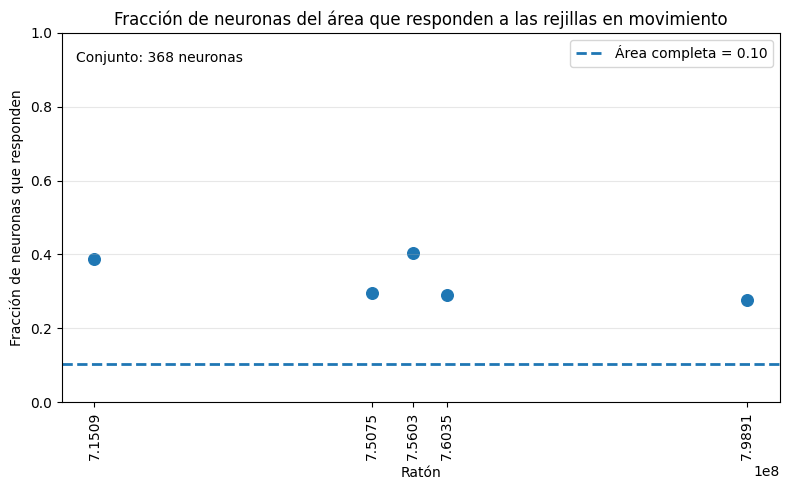

In [106]:
import matplotlib.pyplot as plt

# Fracción de neuronas que responden a las rejillas en movimiento
fraccion_area = neuronas_z_25 / len(neuronas)

print(
    "Fracción de neuronas del área que responden a las rejillas en movimiento:",
    f"{fraccion_area:.2f}"
)

# Datos por ratón
ratones = [fila[0] for fila in fracciones_respondedoras]
fracciones = [fila[2] for fila in fracciones_respondedoras]

# Crear figura
plt.figure(figsize=(8, 5))

# Un punto por ratón
plt.scatter(
    ratones,
    fracciones,
    s=70
)

# Línea horizontal del conjunto completo
plt.axhline(
    y=fraccion_area,
    linestyle="--",
    linewidth=2,
    label=f"Área completa = {fraccion_area:.2f}"
)

# Ejes
plt.xlabel("Ratón")
plt.ylabel("Fracción de neuronas que responden")

# Título
plt.title(
    "Fracción de neuronas del área que responden a las rejillas en movimiento"
)

# Número del conjunto dentro de la figura
plt.text(
    0.02,
    0.95,
    f"Conjunto: {len(neuronas)} neuronas",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

# Etiquetas de los ratones verticales
plt.xticks(
    ratones,
    rotation=90
)

plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

---
## Para cerrar

Anoten su número: **la fracción de neuronas de su área que responden a las rejillas en movimiento**.

Ese número va al póster y es el que comparamos entre las once parejas el viernes 25. Puestos en
orden de área, los once juntos reconstruyen la jerarquía visual del ratón.

Guarden este notebook en su repositorio de GitHub. Es la primera pieza del pipeline del proyecto.